# First mushroom model comparison

**Contributors:** initial scaffold and local verification prepared with AI assistance. Team reviewers and substantive changes will be recorded after review. See [the assistance record](../docs/AI_USE.md).

Compare a majority-class reference, logistic regression and random forest. Positive class `p` is encoded as 1. Preprocessing learns only from training data.

## Run the development experiment

The majority-class dummy is the reference. Logistic regression supplies a simple baseline. Random forest can capture nonlinear interactions. The random forest settings are an initial choice, not a completed tuning exercise. The output reports validation performance at threshold 0.5. No final test labels are evaluated.

In [5]:
from pathlib import Path
import sys
ROOT = Path.cwd()
while not (ROOT / 'src' / 'mushrooms.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open this notebook inside the repository folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from mushrooms import load_data, experiment
results = experiment(load_data())
display(results.round(4))

              model      split  threshold  accuracy  poison_precision  poison_recall     f1  roc_auc  average_precision  tn  fp  fn  tp  fit_seconds  train_accuracy
  majority_baseline validation        0.5     0.621            0.0000         0.0000 0.0000   0.5000              0.379 621   0 379   0        0.146          0.6213
logistic_regression validation        0.5     0.692            0.6802         0.3536 0.4653   0.6776              0.636 558  63 245 134        0.258          0.7130
      random_forest validation        0.5     0.751            0.8457         0.4195 0.5608   0.8016              0.760 592  29 220 159        3.421          0.8937

Rows: training=3000, validation=1000, reserved test=1000
Positive class: p (poisonous/unsafe). Results are validation metrics.


,model,split,threshold,accuracy,poison_precision,poison_recall,f1,roc_auc,average_precision,tn,fp,fn,tp,fit_seconds,train_accuracy
0,majority_baseline,validation,0.5,0.621,0.0000,0.0000,0.0000,0.5000,0.379,621,0,379,0,0.146,0.6213
1,logistic_regression,validation,0.5,0.692,0.6802,0.3536,0.4653,0.6776,0.636,558,63,245,134,0.258,0.7130
2,random_forest,validation,0.5,0.751,0.8457,0.4195,0.5608,0.8016,0.760,592,29,220,159,3.421,0.8937


## Look at errors, not only the ranking

For the positive class `p`, a false negative is a poisonous/unsafe example predicted edible. Inspect several examples and form a specific hypothesis about missing values, rare categories or threshold choice. A probability score has not been calibrated into a reliable real-world confidence.

In [6]:
import pandas as pd
errors = pd.read_csv(ROOT/'reports/mushroom_validation_errors.csv')
print('Validation errors in the RF pilot:', len(errors))
display(errors.head(10))

Validation errors in the RF pilot: 249


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class,poison_probability,predicted_class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p,0.232330,e
1,NaN,NaN,6.61,NaN,f,NaN,NaN,f,x,NaN,NaN,x,p,0.289268,e
2,9.01,8.19,19.25,NaN,n,d,a,p,x,NaN,x,s,p,0.271080,e
3,9.06,7.03,35.75,NaN,w,m,s,f,f,NaN,NaN,x,p,0.171605,e
4,7.80,8.17,18.84,NaN,NaN,d,a,f,x,NaN,f,s,p,0.442916,e
5,4.33,6.29,8.36,NaN,o,d,w,f,f,t,s,x,p,0.214606,e
6,14.30,6.74,45.10,NaN,NaN,d,w,f,f,NaN,s,b,p,0.303075,e
7,7.38,3.28,8.86,NaN,p,d,NaN,NaN,s,NaN,s,x,e,0.507937,p
8,NaN,4.33,3.46,NaN,w,NaN,u,e,b,NaN,f,f,p,0.431765,e
9,1.07,3.93,5.78,NaN,f,NaN,a,f,NaN,NaN,b,NaN,p,0.431577,e


## Next experiments

These are untuned development results. Investigate the missed poisonous examples, threshold choice and the contribution of noisy or highly missing features. Run an automated comparison, tune shortlisted models and preserve AWS evidence before evaluating the reserved test. The [README](../README.md) lists the remaining project tasks.

To explore the saved forest, run `python app/server.py` from the repository root. The interface is a local demonstration.

# Task 11 - How we evaluate mushroom models

**Owner:** Viviana. Some implemantations and initial explanations were prepared with AI assistance; see [the assistance record](../docs/AI_USE.md).

The results above use one fixed split and a threshold of 0.5. Before tuning, we
fix how every model is judged, so all models are compared the same way.

## 1. Split: reserved test and cross-validation

The same 1,000 test rows stay locked away until the final models are chosen. The
other 4,000 rows use stratified 5-fold cross-validation, repeated twice, with
the same folds for every model. This uses all development rows instead of
wasting 1,000 on one fixed validation block. Noise columns are removed as
decided in task 8.

In [7]:
from mushrooms import (development_data, cv_splitter, cross_validated_scores,
                       preprocessor, TARGET_POISON_RECALL)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

X_dev, y_dev, X_test, y_test = development_data(load_data())
print('Development rows:', len(X_dev), '| reserved test rows:', len(X_test), '(not used here)')
print('Poisonous share - development: %.3f, test: %.3f' % (y_dev.mean(), y_test.mean()))
print('Validation folds per model:', cv_splitter().get_n_splits())

Development rows: 4000 | reserved test rows: 1000 (not used here)
Poisonous share - development: 0.379, test: 0.378
Validation folds per model: 10


## 2. Metrics

Poisonous is the positive class: calling a poisonous mushroom edible is the
costly error. Models are ranked by average precision (area under the
precision-recall curve), which focuses on the poisonous class, with ROC-AUC as a
second score. Accuracy is not used because "always edible" already scores 62%.

## 3. Threshold rule

Every model uses the threshold that catches at least 90% of poisonous mushrooms
(sensitivity), chosen on out-of-fold development predictions, never on the test
set. At that threshold we compare specificity: how many edible mushrooms are kept.

In [8]:
candidates = {
    'majority_baseline': (DummyClassifier(strategy='most_frequent'), False),
    'logistic_regression': (LogisticRegression(max_iter=3000), True),
    'random_forest': (RandomForestClassifier(n_estimators=150, min_samples_leaf=3, random_state=42, n_jobs=-1), False),
}
rows, out_of_fold = [], {}
for name, (model, scale) in candidates.items():
    pipeline = Pipeline([('prepare', preprocessor(X_dev, scale=scale)), ('model', model)])
    row, out_of_fold[name] = cross_validated_scores(name, pipeline, X_dev, y_dev)
    rows.append(row)
results = pd.DataFrame(rows).set_index('model')
results.to_csv(ROOT / 'reports/mushroom_cv_metrics.csv')
display(results[['cv_average_precision', 'cv_average_precision_std', 'train_average_precision',
                 'cv_roc_auc', 'threshold', 'poison_recall', 'specificity', 'poison_precision',
                 'tn', 'fp', 'fn', 'tp']].round(3))

,cv_average_precision,cv_average_precision_std,train_average_precision,cv_roc_auc,threshold,poison_recall,specificity,poison_precision,tn,fp,fn,tp
model,,,,,,,,,,,,
majority_baseline,0.379,0.000,0.379,0.500,0.000,1.000,0.000,0.379,0,2485,0,1515
logistic_regression,0.631,0.010,0.654,0.689,0.227,0.902,0.234,0.418,581,1904,149,1366
random_forest,0.783,0.009,0.951,0.833,0.247,0.900,0.432,0.491,1073,1412,151,1364


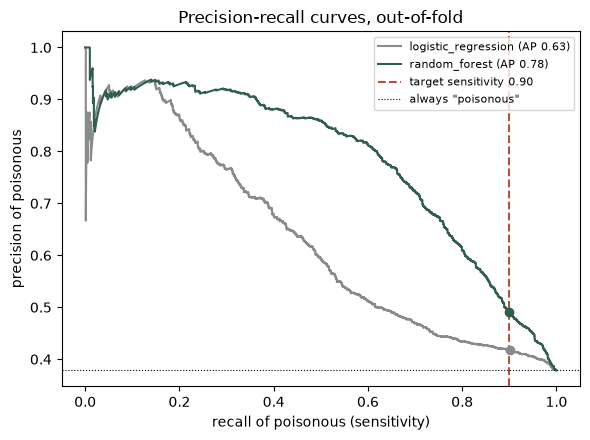

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for name, color in [('logistic_regression', '#8a8a8a'), ('random_forest', '#315f4b')]:
    precision, recall, _ = precision_recall_curve(y_dev, out_of_fold[name])
    ax.plot(recall, precision, color=color, label=f"{name} (AP {results.loc[name, 'cv_average_precision']:.2f})")
    ax.scatter(results.loc[name, 'poison_recall'], results.loc[name, 'poison_precision'], color=color, zorder=3)
ax.axvline(TARGET_POISON_RECALL, color='#b5523b', linestyle='--', label='target sensitivity 0.90')
ax.axhline(y_dev.mean(), color='black', linewidth=.8, linestyle=':', label='always "poisonous"')
ax.set_xlabel('recall of poisonous (sensitivity)'); ax.set_ylabel('precision of poisonous')
ax.set_title('Precision-recall curves, out-of-fold'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## What this completes

Task 11 fixes the evaluation: 1,000 reserved test rows, repeated stratified
5-fold cross-validation on the other 4,000, average precision as the main score
and a threshold that catches 90% of poisonous mushrooms. The random forest stays
clearly the best, but it overfits (training score far above validation) and at
90% sensitivity it still rejects more than half of the edible mushrooms. Tuning
(tasks 20 and 21) should raise average precision so that more edible mushrooms
are kept. The reserved test set has not been used.